In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

In [2]:
init_state = qt.basis(2, 0)

init_state = (-1j*np.pi/4*qt.sigmax()).expm()*init_state

init_state

Quantum object: dims=[[2], [1]], shape=(2, 1), type='ket', dtype=Dense
Qobj data =
[[0.70710678+0.j        ]
 [0.        -0.70710678j]]

In [3]:
epsilon = 0.02
imperfect_U = (-1j*(np.pi/2+epsilon)*qt.sigmax()/2).expm()

In [4]:
states = []

N_range = np.arange(0, 20, 1)

for N in N_range:
    state = (imperfect_U*imperfect_U)**(2*N)*init_state
    states.append(state)

states = np.array(states)

In [5]:
pop1s = [np.abs(states[i][1])**2 for i in range(states.shape[0])]

pop1s_th = [(1+np.sin(4*N*epsilon))/2 for N in np.arange(0, 20, 1)]

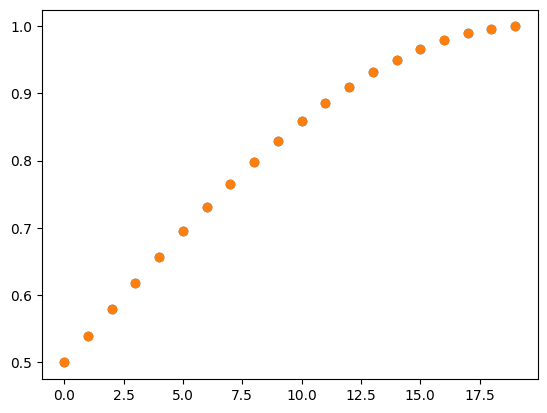

In [6]:
plt.scatter(N_range, pop1s_th)
plt.scatter(N_range, pop1s)

In [7]:
epsilon = 0.001
delta = 0.1

imperfect_U_ed = (-1j*(np.pi/2+epsilon)*qt.sigmax()/2 - 1j*(delta)*qt.sigmaz()).expm()

def factor(epsilon, delta):
    theta = np.pi/2+epsilon
    phi = np.sqrt(theta**2+4*delta**2)
    return theta**2/phi**2

In [8]:
factor(epsilon=6.28*1e-2, delta=3.53*1e-1)

np.float64(0.8426193502753025)

In [9]:
1/(1+(2*3.53*1e-1)**2/(np.pi/2+6.28*1e-2)**2)

0.8426193502753025

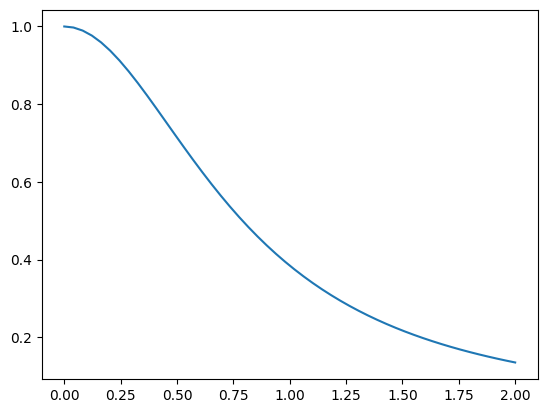

In [10]:
deltas = np.linspace(0, 2, 50)

fig, ax = plt.subplots()
ax.plot(deltas, [factor(epsilon=0.01, delta=d) for d in deltas])

In [76]:
states = []

N_range = np.arange(0, 20, 1)

for N in N_range:
    state = (imperfect_U_ed*imperfect_U_ed)**(2*N)*init_state
    states.append(state)

states = np.array(states)

In [77]:
pop1s = [np.abs(states[i][1])**2 for i in range(states.shape[0])]

pop1s_th = [(1+(theta/phi)*np.sin(4*N*phi))/2 for N in np.arange(0, 20, 1)]

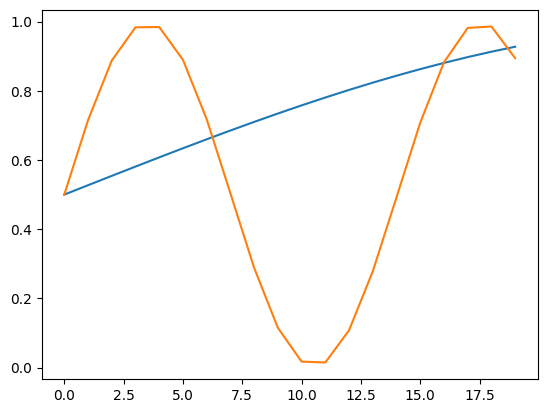

In [78]:
plt.plot(N_range, pop1s)
plt.plot(N_range, pop1s_th)